# Labor Angewandte Physik für IEB/MTB
# Einführung in die Datenanalyse mit Jupyter Notebooks und Python

Literatur zu Messunsicherheiten (zeitgemäße Begrifflichkeiten, Industriestandards werden beachtet):
- Möhrke, Runge: Arbeiten mit Messdaten: Eine praktische Kurzeinführung nach GUM, Springer Spektrum, 2020: https://link.springer.com/book/10.1007/978-3-662-60660-5
- Kapitel 8 aus: Hettich, Jödicke, Sum: Physik Methoden, Springer Spektrum, 2023: https://link.springer.com/book/10.1007/978-3-662-67906-7

Wir benötigen hier keine größeren Programmierkenntnisse. Wir nutzen Pyhton zum Daten einlesen, Daten anzeigen, für einfache Rechnungen und um Daten zu fitten. Einen Einführungskurs in Python und Jupyter Notebooks des physikalischen Anfängerpraktikums an der Uni Heidelberg finden Sie hier:
https://hub.ovh2.mybinder.org/user/nilsleiffischer-python-course-3o5xsc5t/notebooks/index.ipynb

## 1. Vorbereitungen

In Python müssen immer entsprechende Bibliotheken geladen werden, um bestimmte Funktionen nutzen zu können. Diesen Codeblock müssen Sie immer ausführen, wenn Sie Im Folgenden einige Bibliotheken, die wir in diesem Kurs benötigen werden:

In [1]:
# Laden benötigter Bibliotheken
import pandas as pd # Bibliothek zum Einlesen von Daten und Erstellen von Dataframes, Dokumentation: https://pandas.pydata.org/pandas-docs/stable/
import numpy as np # Bibliothek für numerische Berechnungen, Dokumentation: https://numpy.org/doc/stable/
import matplotlib.pyplot as plt # Bibliothek zum Plotten von Daten, Dokumentation: https://matplotlib.org/contents.html
# scipy bietet viele nützliche Funktionen für komplexere Berechnungen, Doku: https://docs.scipy.org/doc/scipy/reference/
# In den vorbereiteten Versuchsnotebooks werden folgende Funktionen geladen:
import scipy as sp # Bibliothek für wissenschaftliches Rechnen
import scipy.special as sc # Bibliothek für spezielle Funktionen, hier für Fitfunktionen etc.
from scipy.optimize import curve_fit # Bibliothek zum Fitten von Daten

## 2. Einlesen und Plotten von Daten

Wir nutzen die Bibliothek `pandas`, um Daten aus einer Textdatei einzulesen und in einem Dataframe - einer Art Tabelle - zu speichern. 
Für Datenanalysen nutzt man folgende Konvention:
- Messgrößen werden in Spalten gespeichert. Hinweis: Vergeben Sie einen sinnvollen Namen für die jeweilige Spalte. Es ist zwar einerseits schön, z.B. die Einheit mit in den Spaltennamen schreiben, aber beim Aufruf der Spalte können Leerzeichen und Sonderzeichen Probleme bereiten. Daher empfiehlt es sich, Einheiten und weitere Informationen zumindest im Jupyter Notebook in Textform zu dokumentieren. Bei Achsenbeschriftungen in Plots sollten Sie die Einheiten dann mit angeben.
- Jede Messung erhält eine eigene Zeile

Zum Darstellen der Daten nutzen wir dann die Bibliothek `matplotlib`.

Als Testdaten nutzen wir 'sofa.txt'. Die Datei enthält 60 Messungen der Breite eines Sofas in cm.

In [2]:
# Einlesen der Daten und überprüfen der Tabelle.
sofa_data = pd.read_csv('Sofa.txt') # Daten aus Physikmethoden Kapitel 8.2a
sofa_data # Anzeigen der Daten (nur letzte Zeile des Codeblocks wird automatisch ausgegeben)

,Breite
0,140
1,140
2,113
3,118
4,140
5,138
6,139
7,119
8,116
9,143


In [3]:
# wenn die Daten sehr groß sind, bietet es sich an, die ersten Zeilen auszugeben, um zu erkennen, ob richtig eingelesen wurde
sofa_data.head() # erste 5 Zeilen des Dataframes ausgeben

,Breite
0,140
1,140
2,113
3,118
4,140


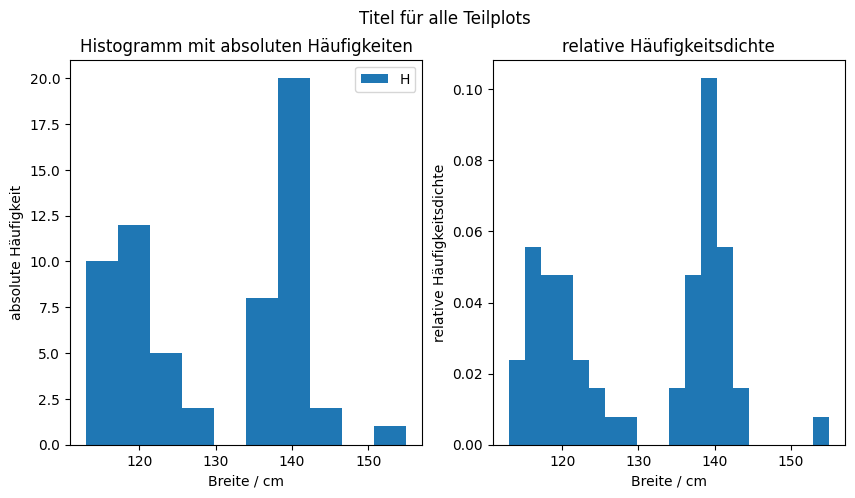

In [4]:
# wenn die Struktur sinnvoll aussieht, können wir die Daten plotten. Bei Mehrfachmessungen einer einzelnen Variable ist der erste Plot immer ein Histogramm.
fig, axs = plt.subplots(1, 2, figsize=(10, 5)) # Erstellen der Achsen, hier zur Demonstration mit 2x1 Achsen. Über fig[index] und axs[index] können dann die verschiedenen Eigenschaften der Achsen konfiguriert werden.
axs[0].hist(sofa_data.Breite) # Darstellen der Daten als Histogramm. Über datenname.Spaltenname kann auf die einzelnen Spalten zugegriffen werden
axs[1].hist(sofa_data.Breite, density=True, bins=20) # density = True skaliert y-Achse so, dass Fläche 1 normiert ist, über bins kann die Anzahl der Klassen engl. bins festgelegt werden
axs[0].set_xlabel('Breite / cm') # Beschriften der x-Achse
axs[0].set_ylabel('absolute Häufigkeit') # Beschriften der y-Achse
axs[0].legend('Histogramm') # Legende anzeigen
axs[0].set_title('Histogramm mit absoluten Häufigkeiten') # Titel des Subplots
axs[1].set_xlabel('Breite / cm') # Beschriften der x-Achse
axs[1].set_ylabel('relative Häufigkeitsdichte') # Beschriften der y-Achse
axs[1].set_title('relative Häufigkeitsdichte') # Titel des Subplots
fig.suptitle('Titel für alle Teilplots') # Titel aller Plots
plt.show() # Plot anzeigen

Wenn Sie nicht mit Histogrammen vertraut sind, machen Sie sich folgende Eigenschaften bewusst:
- ein Histogramm ist eine flächentreue Darstellung von Häufigkeiten. Wichtig ist nicht allein die Höhe der Balken, sondern auch die Breite. Zum Test können Sie die Anzahl der bins verändern und die y-Achse beobachten.
- die Anzahl der bins kann das Aussehen eines Histogramms deutlich verändern, je nachdem wie die Daten verteilt sind. Zu viele bins sind nutzlos, zu wenige verfälschen die Darstellung aber auch. Da hilft nur bei jedem Datensatz neu ausprobieren und etwas herumspielen.

## 3. Bestimmung von statistischen Unsicherheiten (Typ-A)

Bei Wiederholungsmessungen lässt sich die statistische Unsicherheit, die sog. Typ-A Unsicherheit aus den Wiederholungsmessungen bestimmen. Vor jeder Berechnung sollten immer zuerst die Daten in einem Histogramm angeschaut werden. 
 
Gehen Sie folgendermaßen vor:
- Schauen Sie die Daten im Histogramm an. Handelt es sich um eine Verteilung? Gibt es Ausreißer, die nicht zur Verteilung passen?
- Bereinigen Sie die Daten (Dokumentation!). Syntaxbeispiel: Auswahl von Zeilen mit Spalte Breite größer x0: `sofa_data[sofa_data.Breite > x0]` (analog, <, ==, !=)
- Berechnen Sie den Mittelwert, die Standardabweichung der Daten und den Standardfehler des Mittelwerts. Sollten die Daten sich stark von einer Normalverteilung unterscheiden, ist zu überlegen, ob andere Parameter für die Beschreibung des Messergebnisses sinnvoller sind.

Berechnungsformeln für statistische Größen sind in numpy und scipy implementiert.
Leider ist die default - Festlegung der Freiheitsgrade bei Standardabweichung/Varianz/Kovarianz etc. in den verschiedenen Bibliotheken nicht einheitlich. Legen Sie daher die Freiheitsgrade (ddof) immer selbst explizit fest, damit Sie wissen, was Sie berechnen.
In der deskriptiven Statistik wird klassischerweise mit 1/n (n = Stichprobengröße) gerechnet. In der induktiven Statistik wird 1/(n-1) genutzt, um einen erwartungstreuen Schätzer zu erhalten. Es ist sinnvoll immer 1/(n-1) zu nutzen. In python ist das der Parameter `ddof=1` (degrees of freedom).
- Mittelwert: `np.mean(data)` oder 'sp.mean(data)'
- Standardabweichung: `np.std(data, ddof=1)` oder 'sp.stats.std(data, ddof=1)'
- Standardfehler des Mittelwerts: `np.std(data, ddof=1)/np.sqrt(len(data))` oder 'sp.stats.sem(data)'

Stellen Sie Ihr Messergebnis als Mittelwert ± Standardfehler des Mittelwerts mit sinnvoller Anzahl signifikanter Stellen dar.


In [5]:
# Bereinigung der Daten (incl. Dokumentation!)
# Wir filtern die Daten, sodass nur Werte zwischen 130 und 150 cm übrig bleiben (die Außenbreite des Sofas ohne den Ausreißer 155 cm)
sofa_data_bereinigt = sofa_data[(sofa_data.Breite > 130) & (sofa_data.Breite < 150)]
sofa_data_bereinigt


,Breite
0,140
1,140
4,140
5,138
6,139
9,143
10,139
11,140
13,139
19,136


In [7]:
# Berechnung des Messergebnisses
print('Messergebnis für die sofa_breite:', np.round(np.mean(sofa_data_bereinigt.Breite), 2), '±', np.round(sp.stats.sem(sofa_data_bereinigt.Breite), 2), 'cm') # Ausgabe des Messergebnisses

Messergebnis für die sofa_breite: 139.53 ± 0.35 cm


Berechnen Sie noch einmal zum Vergleich die Standardabweichung der bereinigten Messwerte. Dies ist eine Schätzung für die Unsicherheit einer Einzelmessung:

In [8]:
print('Unsicherheit der Einzelmessung:', np.round(np.std(sofa_data_bereinigt.Breite, ddof=1), 2), 'cm')

Unsicherheit der Einzelmessung: 1.91 cm


## 4. Kombinierte Messunsicherheiten und Abschätzung relevanter Unsicherheiten bei mehreren Messgrößen

Typ-A und Typ-B Unsicherheiten können/müssen kombiniert werden. Bei Abhängigkeit der Messgröße von mehreren Parametern gilt im Falle vollständig unkorrelierter Eingangsgrößen:

$u_c(z)= \sqrt{\left(\frac{\partial z}{\partial a}\cdot u(a)\right)^2+\left(\frac{\partial z}{\partial b}\cdot u(b)\right)^2}+\dots$

#### Beispiel: Messung des elektrischen Widerstands eines Drahts:

Für den spezifischen Widerstand gilt:
$\rho =R \frac{A}{l}$

Der Widerstand wird aus einer Strom- und Spannungsmessung bestimmt.

Folgende Unsicherheiten der Messmittel liegen vor:
Voltmeter mit Messbereich 150mV hat laut Datenblatt eine Unsicherheit von 2%.
Amperemeter: $\Delta I = 0.1 mA$ (Tpy-B Unsicherheit aus Datenblatt)
Geodreieck zur Längenmessung des Drahts: $\Delta l = 1 mm$ (Typ-B Unsicherheit angenommen)
Schieblehre zur Messung des Drahtdurchmessers: $\Delta d = 0.1 mm$ (Typ-B Unsicherheit angenommen)

Folgende Messergebnisse liegen vor: $U = 21.6 mV$, $I = 2.4 mA$, $l = 1.1 m$, $d = 0.4 mm$

Bestimmen Sie die Unsicherheit des spezifischen Widerstands $\Delta \rho$ und überlegen Sie, an welchen Stellen sich die Messung am effizientesten verbessern ließe.

In [9]:
# TODO: Berechnen Sie die Unsicherheit des spezifischen Widerstands (diese Aufgabe erledigt sich besser auf einem Blatt Papier)

## 6. Fitten von Daten

Häufig wird nicht nur ein Parameter gemessen, sondern die Abhängigkeit von zwei (oder mehr) Größen untersucht oder es soll aus der Abhängigkeit mehrerer Größen auf eine unbekannte Größe geschlossen werden. Hier versuchen Sie aus dem Zusammenhang von Periodendauer und Pendellänge, die Erdbeschleungigung zu bestimmen.

Für ein einfaches Fadenpendel gilt:
$m l \frac{d^2 \alpha}{dt^2} = - m g \sin{\alpha}$

Bei kleinen Auslenkungen lässt sich $\sin{\alpha} \approx \alpha$ nähern und damit ist das näherungsweise eine harmonische Schwingung mit Kreisfrequenz:
$\omega = \sqrt{\frac{g}{l}}$

Damit haben wir einen einfachen Zusammenhang zwischen Periodendauer und Länge:

$T^2 = 4 \pi^2 \frac{l}{g}$

Im Folgenden nutzen Sie den Datensatz 'pendel.txt' um die Erdbeschleunigung zu bestimmen.


In [10]:
# Daten einlesen
pendel_data = pd.read_csv('pendel.txt', sep='\t')
pendel_data.head()

,Laenge / cm,10 Perioden / s
0,30.5,10.10
1,43.0,12.96
2,54.0,15.13
3,67.0,16.51
4,81.5,18.33


In [11]:
# Fügen Sie zwei Tabellenspalten hinzu mit der Länge in m und 1 Periode:
pendel_data['Laenge'] = pendel_data['Laenge / cm'] / 100
pendel_data['Periode'] = pendel_data['10 Perioden / s'] / 10
pendel_data.head()

,Laenge / cm,10 Perioden / s,Laenge,Periode
0,30.5,10.10,0.305,1.010
1,43.0,12.96,0.430,1.296
2,54.0,15.13,0.540,1.513
3,67.0,16.51,0.670,1.651
4,81.5,18.33,0.815,1.833


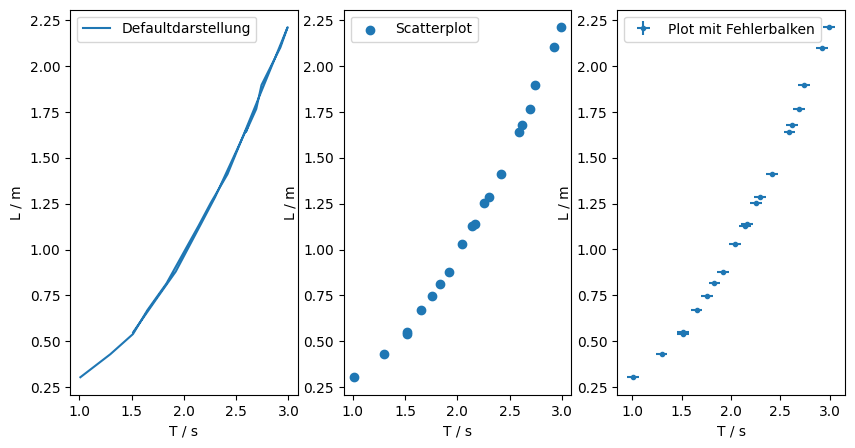

In [12]:
# x-y-Diagramm der Daten erstellen
fig, axs = plt.subplots(1, 3, figsize=(10, 5))
axs[0].plot(pendel_data['Periode'], pendel_data['Laenge'], label='Defaultdarstellung') # per default werden die Daten als Linie geplottet, das ist nicht wissenschaftlich. Vermeiden Sie solche Plots! Stellen Sie immer die Einzelwerte dar, sodass z.B. Messlücken erkennbar bleiben. besser: scatterplot (oder .plot mit 'o' oder 'x' etc.)
axs[1].scatter(pendel_data['Periode'], pendel_data['Laenge'], label='Scatterplot') 
axs[2].errorbar(pendel_data['Periode'], pendel_data['Laenge'], xerr=2*0.3/10, yerr=0.001, fmt='.', label='Plot mit Fehlerbalken') # Alternativ können Sie auch einen Plot mit Fehlerbalken wählen und die Unsicherheiten der Messungen eintragen. Hier wird per default auch ein Linienplot erstellt, wählen Sie daher eine Darstellung für die Marker. Hier z.B: fmt='.' für kleine Punkte. (https://matplotlib.org/stable/api/markers_api.html)
axs[0].set_ylabel('L / m')
axs[0].set_xlabel('T / s')
axs[0].legend()
axs[1].set_ylabel('L / m')
axs[1].set_xlabel('T / s')
axs[1].legend()
axs[2].set_ylabel('L / m')
axs[2].set_xlabel('T / s')
axs[2].legend()
plt.show()

Legen Sie nun einen Fit durch die Daten und überprüfen Sie den Fit anhand des Residuendiagramms. Aus dem Fitparameter können Sie dann die Erdbeschleunigung bestimmen, aus der Kovarianzmatrix die Unsicherheit des Fits und damit die der Messung der Erdbeschleunigung.

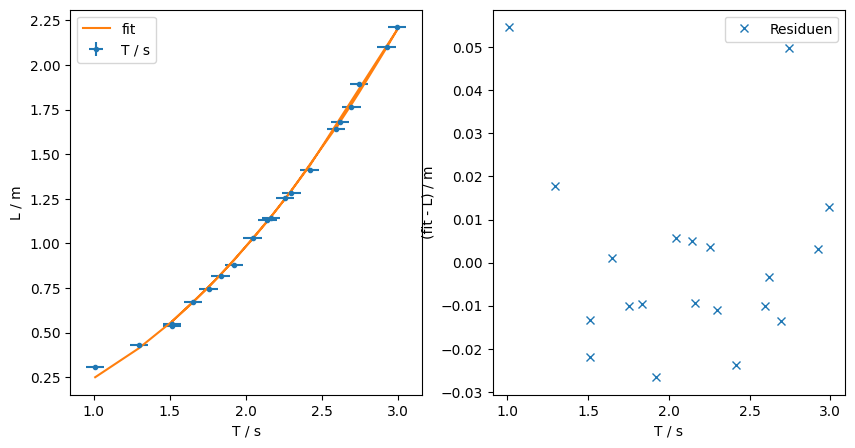

In [13]:
# Definition der Fitfunktion:
def fitfunction(x, g):
    # Hier können relativ beliebig mathematische Funktionen verwendet werden, z.B. np.exp(x) für die Exponentialfunktion
    # x steht für die übergebenen x-Werte, g für den Fitparameter. Es können auch mehrere Parameter gefittet werden.
    # Stellen Sie eine Funktion auf, die den Zusammenhang der Daten beschreibt. g sollte die Erdbeschleunigung sein.
    return g / (4 * np.pi**2) * x**2

# Damit der Fit konvergiert, müssen Sie evtl. sinnvolle Startwerte für die Parameter angeben. (bei mehreren Parametern meist nötig)
## Startwert für die Erdbeschleunigung g:
initial_guess = [9.81] # es wird ein array übergeben. Hier haben Sie nur einen Parameter.

# Weitere Parameter (hier nicht nötig):

# Es kann nötig sein, die Fitfunktion f auf einen gewisen Wertebereich zu beschränken, z.B. falls eine Wurzelfunktion vorkommt.
# param_bounds=([0],[np.inf])

# Falls nötig können Sie den x-Bereich einschränken, um den Fit zu verbessern, z.G. auf Werte größer als 15:
# fitr_l = 15

# Daten fitten:
# Ausgabe sind die gefitteten Parameter und die Kovarianzmatrix
import scipy.optimize
params, covariance = scipy.optimize.curve_fit(fitfunction, pendel_data.Periode, pendel_data.Laenge, p0=initial_guess)#, bounds=param_bounds)

# Daten, Fit und Residuen plotten: 
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].errorbar(pendel_data.Periode, pendel_data.Laenge, xerr=2*0.3/10, yerr=0.001, fmt='.', label='T / s')
axs[0].plot(pendel_data.Periode, fitfunction(pendel_data.Periode, params[0]), label='fit')
axs[1].plot(pendel_data.Periode, pendel_data.Laenge-fitfunction(pendel_data.Periode, params[0]), 'x', label='Residuen')
axs[0].set_xlabel('T / s')
axs[0].set_ylabel('L / m')
axs[0].legend()
axs[1].set_ylabel('(fit - L) / m')
axs[1].set_xlabel('T / s')
axs[1].legend()
plt.show()

In [14]:
# Bestimmung des Messergebnisses:

# Gefittete Parameter und Kovarianzmatrix ausgeben. 
print('Gefittete Parameter: ', params, 'Kovarianzmatrix: ', covariance)
# Die Unsicherheiten der gefitteten Parameter sind die Wurzeln der Diagonalelemente der Kovarianzmatrix:
perr = np.sqrt(np.diag(covariance))
print('Unsicherheiten der Parameter: ', perr)

# Ausgabe des Messergebnisses:
print('Erdbeschleunigung: ', np.round(params[0],3), '±', np.round(perr[0],3), 'm/s^2')

Gefittete Parameter:  [9.68881904] Kovarianzmatrix:  [[0.00126957]]
Unsicherheiten der Parameter:  [0.035631]
Erdbeschleunigung:  9.689 ± 0.036 m/s^2


Passt das Messergebnis zu Ihrer Erwartung? Wenn nein, woran könnte das liegen?

Vorsicht: der Fit minimiert die Summe der quadrierten Abweichungen in y-Richtung. Das bedeutet, dass nur die Unsicherheiten in y-Richtung im Fit berücksichtigt werden!
Passt diese Information zu den Unsicherheiten, die Sie bei den Messungen beobachtet/abgeschätzt haben bzw. die in Ihren Fehlerbalken angegeben sind?

Wenn nicht: Plotten Sie die Daten so, dass die Variable mit der größeren Unsicherheit auf der y-Achse liegt und führen Sie den Fit erneut durch und überprüfen Sie ob Sie so ein passenderes Messergebnis (ein Messergebnis beinhaltet immer eine Unsicherheit) erhalten.


In [15]:
# Fit mit größeren Unsicherheiten auf der y-Achse
y_fehler = 0.001
import scipy.optimize
params_neu, covariance_neu = scipy.optimize.curve_fit(fitfunction, pendel_data.Periode, pendel_data.Laenge, p0=initial_guess, sigma=np.full(len(pendel_data), y_fehler), absolute_sigma=True)
perr_neu = np.sqrt(np.diag(covariance_neu))
print('Erdbeschleunigung (gewichteter Fit):', np.round(params_neu[0],3), '±', np.round(perr_neu[0],3), 'm/s^2')

Erdbeschleunigung (gewichteter Fit): 9.689 ± 0.002 m/s^2
